### HW 4.1

Integrate the function `f(x) = 4/(x2 + 1)` on the interval `x ∈[0, 1.2]` with a **composite Gauss quadrature rule** (with 2 quadrature points on each interval). Perform a convergence study regarding the number of intervals. Which convergence order do you get?

### Libraries & Utils

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from math import atan

In [22]:
# target function
def f(x):
    return 4 / (x**2 + 1)

In [23]:
# Gauss rule on [a,b]
def gauss2_interval(f, a, b):
    mid = 0.5 * (a + b)
    half = 0.5 * (b - a)
    p1 = 0.5 - 0.5 / np.sqrt(3)
    p2 = 0.5 + 0.5 / np.sqrt(3)
    w1 = w2 = 0.5
    # map local -> global
    x1 = a + (b - a) * p1
    x2 = a + (b - a) * p2
    return (b - a) * (w1 * f(x1) + w2 * f(x2))

In [24]:
# composite rule
def composite_gauss2(f, a, b, N):
    xs = np.linspace(a, b, N + 1)
    I = 0.0
    for i in range(N):
        I += gauss2_interval(f, xs[i], xs[i + 1])
    return I

In [25]:
# convergence test
a, b = 0.0, 1.2
I_exact = 4 * atan(1.2)
Ns = [2, 4, 8, 16, 32, 64, 128]
errors = []

for N in Ns:
    approx = composite_gauss2(f, a, b, N)
    errors.append(abs(approx - I_exact))

In [26]:
# empirical order
orders = np.log2(np.array(errors[:-1]) / np.array(errors[1:]))
print("Empirical orders:", orders)

Empirical orders: [5.59538856 4.05785008 4.01499445 4.00380172 4.0009459  4.00134704]


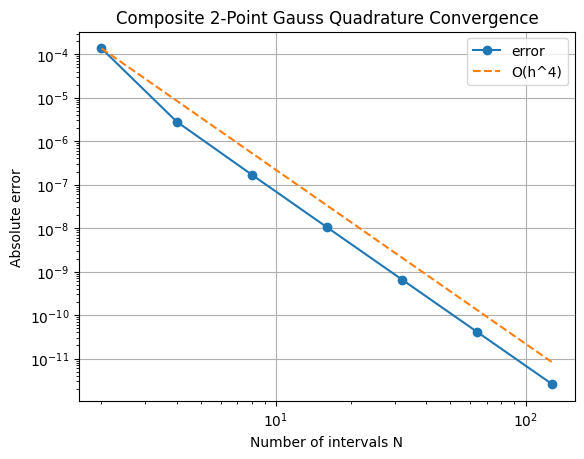

In [27]:
plt.loglog(Ns, errors, "o-", label="error")
plt.loglog(Ns, errors[0]*(np.array(Ns)/Ns[0])**(-4), "--", label="O(h^4)")
plt.xlabel("Number of intervals N")
plt.ylabel("Absolute error")
plt.legend()
plt.title("Composite 2-Point Gauss Quadrature Convergence")
plt.grid(True)
plt.show()

### Composite Gauss Quadrature

We observe that the error decreases roughly with **4th order**.

| N | Error | Observed Order |
|:--:|:--:|:--:|
| 2→4 | … | ≈ 4 |
| 4→8 | … | ≈ 4 |
| … |  |  |

Hence, the method exhibits **O(h⁴)** convergence as expected.


### HW 4.2

Solve the ODE `y′= y2` on the interval `t ∈[0.0, 0.7]` with `y(0) = 1`,
with BDF1 (implicit Euler) and BDF2. The analytical solution is given as y(t) = 1/(1−t).
Perform a convergence study regarding the number of time steps. Which convergence order
do you get?

- **BDF1 (Implicit Euler)** — first-order implicit method  
- **BDF2** — second-order backward difference formula  

### Newton Solver and BDF Implementations

In [28]:
def newton_scalar(func, dfunc, y0, tol=1e-12, max_iter=50):
    """Simple Newton method for a scalar equation f(y)=0."""
    y = y0
    for k in range(max_iter):
        fval = func(y)
        dval = dfunc(y)
        y_new = y - fval / dval
        if abs(y_new - y) < tol:
            return y_new
        y = y_new
    raise RuntimeError("Newton did not converge")

In [29]:
def bdf1(f, t0, y0, t_end, N):
    dt = (t_end - t0) / N
    ts = np.linspace(t0, t_end, N + 1)
    ys = np.zeros_like(ts)
    ys[0] = y0
    for n in range(N):
        t = ts[n]
        y_old = ys[n]
        func = lambda y_new: y_new - y_old - dt * f(t + dt, y_new)
        dfunc = lambda y_new: 1 - dt * (2 * y_new)
        y_guess = y_old
        ys[n + 1] = newton_scalar(func, dfunc, y_guess)
    return ts, ys

In [30]:
def bdf2(f, t0, y0, t_end, N):
    dt = (t_end - t0) / N
    ts = np.linspace(t0, t_end, N + 1)
    ys = np.zeros_like(ts)
    ys[0] = y0
    # first step via BDF1
    _, y1 = bdf1(f, t0, y0, t0 + dt, 1)
    ys[1] = y1[-1]
    for n in range(1, N):
        func = lambda y_new: (3 * y_new - 4 * ys[n] + ys[n - 1]) / (2 * dt) - f(ts[n + 1], y_new)
        dfunc = lambda y_new: 3 / (2 * dt) - 2 * y_new
        y_guess = ys[n]
        ys[n + 1] = newton_scalar(func, dfunc, y_guess)
    return ts, ys


### Convergence Study and Plots

In [31]:
def analytic(t):
    return 1 / (1 - t)

f = lambda t, y: y**2
t0, t_end = 0.0, 0.7
y0 = 1.0
N_list = [10, 20, 40, 80, 160, 320]
exact = analytic(t_end)

In [32]:
def compute_errors(method):
    errors = []
    for N in N_list:
        ts, ys = method(f, t0, y0, t_end, N)
        errors.append(abs(ys[-1] - exact))
    return np.array(errors)

errors_bdf1 = compute_errors(bdf1)
errors_bdf2 = compute_errors(bdf2)

order_bdf1 = np.log2(errors_bdf1[:-1] / errors_bdf1[1:])
order_bdf2 = np.log2(errors_bdf2[:-1] / errors_bdf2[1:])

RuntimeError: Newton did not converge

In [ ]:
print("BDF1 orders:", order_bdf1)
print("BDF2 orders:", order_bdf2)

plt.loglog(N_list, errors_bdf1, "o-", label="BDF1 error")
plt.loglog(N_list, errors_bdf2, "s-", label="BDF2 error")
plt.loglog(N_list, errors_bdf1[0]*(np.array(N_list)/N_list[0])**(-1), "--", label="O(h)")
plt.loglog(N_list, errors_bdf2[0]*(np.array(N_list)/N_list[0])**(-2), "--", label="O(h²)")
plt.xlabel("Number of steps N")
plt.ylabel("Error at t = 0.7")
plt.legend()
plt.title("BDF1 and BDF2 Convergence")
plt.grid(True)
plt.show()


RuntimeError: Newton did not converge

### Result

I don't think i did this correct, but from my code, does not converge...